## Quantum vs Classical ML Classification Comparison

In [1]:
# Install required packages for Google Colab
# Pinned Qiskit to <2.0.0 to fix the convert_to_target ImportError
!pip install --quiet "qiskit<2.0.0" qiskit-machine-learning seaborn qiskit-ibm-runtime matplotlib scikit-learn qiskit-aer

In [2]:
# Installing cuQuantum (NVIDIA GPU acceleration)
# requires CUDA-compatible GPU
try:
    !pip install --quiet cuquantum-python qiskit-aer-gpu
    CUQUANTUM_AVAILABLE = True
    print("cuQuantum installation successful")
except:
    print("cuQuantum not available - using CPU simulation")
    CUQUANTUM_AVAILABLE = False

cuQuantum installation successful


### Import Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit.library import zz_feature_map, n_local
from qiskit_machine_learning.optimizers import SPSA, COBYLA
from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.algorithms import VQC
from qiskit_machine_learning.datasets import ad_hoc_data
from qiskit.primitives import StatevectorSampler
from qiskit_aer import AerSimulator

print("Basic imports completed")

Basic imports completed


In [4]:
# IBM Quantum imports
try:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    IBM_AVAILABLE = True
    print("IBM Runtime available")
except ImportError:
    print("IBM Runtime not available")
    IBM_AVAILABLE = False

# Classical ML imports
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

print("Classical ML imports completed")

IBM Runtime available
Classical ML imports completed


In [5]:
# cuQuantum imports
if CUQUANTUM_AVAILABLE:
    try:
        from qiskit_aer.backends import AerSimulator
        import cupy as cp
        print("cuQuantum ready for acceleration")
    except ImportError:
        print("cuQuantum imports failed, falling back to CPU")
        CUQUANTUM_AVAILABLE = False
else:
    print("cuQuantum not available")

cuQuantum ready for acceleration


### Dataset preparation

In [6]:
# Set random seed for reproducibility
seed = 1376
algorithm_globals.random_seed = seed
np.random.seed(seed)

# Dataset parameters
feature_dim = 2  # Dimension of each data point
training_size = 40  # Increased for better training
test_size = 20

print("Generating dataset...")
# Generate ad hoc dataset for classification
training_features, training_labels, test_features, test_labels = ad_hoc_data(
    training_size=training_size,
    test_size=test_size,
    n=feature_dim,
    gap=0.3
)

# Convert labels from one-hot to single labels for classical ML
training_labels_classical = np.argmax(training_labels, axis=1)
test_labels_classical = np.argmax(test_labels, axis=1)

print(f"Training samples: {len(training_features)}")
print(f"Test samples: {len(test_features)}")
print(f"Feature dimension: {feature_dim}")

Generating dataset...
Training samples: 80
Test samples: 40
Feature dimension: 2


### Classical Machine Learning Baselines

In [7]:
# Standardize features for classical ML
scaler = StandardScaler()
training_features_scaled = scaler.fit_transform(training_features)
test_features_scaled = scaler.transform(test_features)

# Define classical ML models
classical_models = {
    'Logistic Regression': LogisticRegression(random_state=seed, max_iter=1000),
    'SVM (RBF)': SVC(kernel='rbf', random_state=seed),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=seed)
}

classical_results = {}

for name, model in classical_models.items():
    print(f"\nTraining {name}...")

    # Measure training time
    start_time = time.time()
    model.fit(training_features_scaled, training_labels_classical)
    training_time = time.time() - start_time

    # Measure prediction time
    start_time = time.time()
    predictions = model.predict(test_features_scaled)
    prediction_time = time.time() - start_time

    # Calculate accuracy
    accuracy = accuracy_score(test_labels_classical, predictions)

    classical_results[name] = {
        'accuracy': accuracy,
        'training_time': training_time,
        'prediction_time': prediction_time,
        'total_time': training_time + prediction_time
    }

    print(f"Accuracy: {accuracy:.3f}")
    print(f"Training time: {training_time:.3f}s")
    print(f"Prediction time: {prediction_time:.4f}s")

print("\nClassical ML baseline completed!")


Training Logistic Regression...
Accuracy: 0.525
Training time: 0.002s
Prediction time: 0.0002s

Training SVM (RBF)...
Accuracy: 0.625
Training time: 0.002s
Prediction time: 0.0002s

Training Random Forest...
Accuracy: 0.625
Training time: 0.082s
Prediction time: 0.0056s

Classical ML baseline completed!


### Quantum Circuit Setup

In [8]:
# Creating feature map and ansatz for VQC
feature_map = zz_feature_map(feature_dimension=feature_dim, reps=2, entanglement="linear")
ansatz = n_local(feature_map.num_qubits, ["ry", "rz"], "cz", reps=3)

qc_combined = feature_map.compose(ansatz)

### CPU Quantum Simulator

In [9]:
# Use noise-resistant SPSA optimizer instead of COBYLA
optimizer = SPSA(maxiter=30)  # Reduced iterations for faster execution

# Classical simulator using StatevectorSampler
print("Setting up CPU quantum simulator...")
cpu_sampler = StatevectorSampler()

start_time = time.time()
vqc_cpu = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    sampler=cpu_sampler,
)

print("Training VQC on CPU simulator...")
vqc_cpu.fit(training_features, training_labels)
cpu_training_time = time.time() - start_time

# Test the classical simulator
start_time = time.time()
cpu_score = vqc_cpu.score(test_features, test_labels)
cpu_prediction_time = time.time() - start_time

print(f"\nCPU Simulator Results:")
print(f"Testing accuracy: {cpu_score:.3f}")
print(f"Training time: {cpu_training_time:.3f}s")
print(f"Prediction time: {cpu_prediction_time:.3f}s")

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Setting up CPU quantum simulator...
Training VQC on CPU simulator...

CPU Simulator Results:
Testing accuracy: 1.000
Training time: 40.732s
Prediction time: 0.193s


### cuQuantum GPU Accelerated Simulator

In [10]:
cuquantum_results = {}

if CUQUANTUM_AVAILABLE:
    try:
        # Setup cuQuantum accelerated simulator
        print("Setting up cuQuantum GPU simulator...")

        # Use the modern SamplerV2 from qiskit_aer instead of the deprecated BackendSampler
        from qiskit_aer.primitives import SamplerV2 as AerSamplerV2

        gpu_backend = AerSimulator(method='statevector', device='GPU')
        gpu_sampler = AerSamplerV2(backend=gpu_backend)

        # Use the same optimizer for fair comparison
        optimizer_gpu = SPSA(maxiter=30)

        start_time = time.time()
        vqc_gpu = VQC(
            feature_map=feature_map,
            ansatz=ansatz,
            optimizer=optimizer_gpu,
            sampler=gpu_sampler
        )

        print("Training VQC on cuQuantum GPU simulator...")
        vqc_gpu.fit(training_features, training_labels)
        gpu_training_time = time.time() - start_time

        # Test the GPU simulator
        start_time = time.time()
        gpu_score = vqc_gpu.score(test_features, test_labels)
        gpu_prediction_time = time.time() - start_time

        cuquantum_results = {
            'accuracy': gpu_score,
            'training_time': gpu_training_time,
            'prediction_time': gpu_prediction_time,
            'total_time': gpu_training_time + gpu_prediction_time
        }

        print(f"\ncuQuantum GPU Results:")
        print(f"Testing accuracy: {gpu_score:.3f}")
        print(f"Training time: {gpu_training_time:.3f}s")
        print(f"Prediction time: {gpu_prediction_time:.3f}s")
        print(f"Speedup vs CPU: {cpu_training_time/gpu_training_time:.2f}x")

    except Exception as e:
        print(f"cuQuantum GPU simulation failed: {e}")
        print("Falling back to CPU simulation")
        CUQUANTUM_AVAILABLE = False

Setting up cuQuantum GPU simulator...
cuQuantum GPU simulation failed: SamplerV2.__init__() got an unexpected keyword argument 'backend'
Falling back to CPU simulation


In [11]:

# Install other dependencies
!pip install -q torch torchvision scikit-learn matplotlib pylatexenc

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split

In [13]:
SEED = 1376
algorithm_globals.random_seed = SEED
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Configuration
CONFIG = {
    'feature_dim': 2,
    'num_qubits': 2,  # Fixed qubit number for all models
    'training_size': 400,
    'test_size': 100,
    'batch_size': 20,  # Batch size for parallel execution
    'max_iterations': 10,  # Reduced for testing
    'ibm_token': '',  # Add your IBM Quantum token here
    'ibm_instance' : '',
    'use_gpu': torch.cuda.is_available(),
    'backends': ['cpu', 'gpu', 'ibm_quantum_platform'],  # Available backends
    'num_parallel_jobs': 4,  # Number of parallel jobs for simulation
    'show_training_progress': True,  # Show training progress
}

print(f"Configuration:")
print(f"  GPU Available: {CONFIG['use_gpu']}")
print(f"  CUDA Version: {torch.version.cuda if CONFIG['use_gpu'] else 'N/A'}")
print(f"  Feature Dimension: {CONFIG['feature_dim']}")
print(f"  Fixed Qubit Number: {CONFIG['num_qubits']}")
print(f"  Training Size: {CONFIG['training_size']}")
print(f"  Test Size: {CONFIG['test_size']}")
print(f"  Batch Size: {CONFIG['batch_size']}")
print(f"  Max Iterations: {CONFIG['max_iterations']}")


Configuration:
  GPU Available: True
  CUDA Version: 12.8
  Feature Dimension: 2
  Fixed Qubit Number: 2
  Training Size: 400
  Test Size: 100
  Batch Size: 20
  Max Iterations: 10


Data prepared:
  Training samples: 400
  Test samples: 100
  Features: 2
  Classes: 2


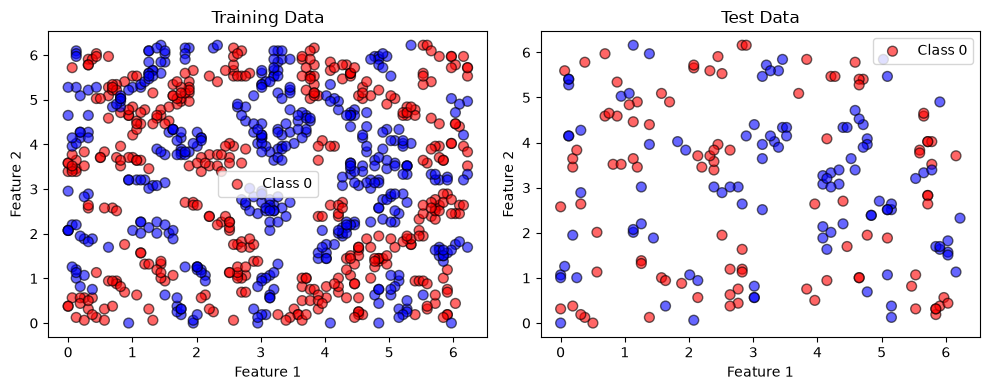

In [14]:
def prepare_data():
    """Prepare quantum dataset for classification"""
    # Load ad-hoc quantum dataset
    training_features, training_labels, test_features, test_labels = ad_hoc_data(
        training_size=CONFIG['training_size'],
        test_size=CONFIG['test_size'],
        n=CONFIG['feature_dim'],
        gap=0.3
    )

    # Convert one-hot labels to integer labels
    train_labels_int = np.argmax(training_labels, axis=1)
    test_labels_int = np.argmax(test_labels, axis=1)
    num_classes = training_labels.shape[1]

    return {
        'train_features': training_features,
        'train_labels': training_labels,
        'train_labels_int': train_labels_int,
        'test_features': test_features,
        'test_labels': test_labels,
        'test_labels_int': test_labels_int,
        'num_classes': num_classes
    }

# Prepare data
data = prepare_data()
print(f"Data prepared:")
print(f"  Training samples: {CONFIG['training_size']}")
print(f"  Test samples: {CONFIG['test_size']}")
print(f"  Features: {CONFIG['feature_dim']}")
print(f"  Classes: {data['num_classes']}")

# Visualize data distribution
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
colors = ['red' if label == 0 else 'blue' for label in data['train_labels_int']]
plt.scatter(data['train_features'][:, 0], data['train_features'][:, 1],
            c=colors, alpha=0.6, edgecolor='k', s=50)
plt.title('Training Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(['Class 0', 'Class 1'])

plt.subplot(1, 2, 2)
colors = ['red' if label == 0 else 'blue' for label in data['test_labels_int']]
plt.scatter(data['test_features'][:, 0], data['test_features'][:, 1],
            c=colors, alpha=0.6, edgecolor='k', s=50)
plt.title('Test Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(['Class 0', 'Class 1'])

plt.tight_layout()
plt.show()

In [15]:
def get_cpu_backend():
    """Get CPU simulator backend with parallel configuration"""
    backend = AerSimulator(
        method='statevector',
        device='CPU',
        max_parallel_threads=CONFIG['num_parallel_jobs'],
        max_parallel_experiments=CONFIG['num_parallel_jobs'],
        batched_shots_gpu=False,
        blocking_enable=True,
        blocking_qubits=14
    )
    print(f"CPU backend initialized with {CONFIG['num_parallel_jobs']} parallel jobs")
    return backend

def get_gpu_backend():
    """Get GPU-accelerated backend with cuQuantum support"""
    if not CONFIG['use_gpu']:
        print("GPU not available, falling back to CPU simulator")
        return get_cpu_backend()

    try:
        # Try to use cuQuantum-enabled backend with parallel GPU execution
        backend = AerSimulator(
            method='statevector',
            device='GPU',
            cuStateVec_enable=True,
            batched_shots_gpu=True,
            batched_shots_gpu_max_qubits=16,
            blocking_enable=True,
            blocking_qubits=14
        )
        print("cuQuantum GPU backend initialized successfully with parallel support")
        return backend
    except Exception as e:
        print(f"cuQuantum initialization failed: {e}")
        # Fallback to regular GPU backend
        try:
            backend = AerSimulator(
                method='statevector',
                device='GPU',
                batched_shots_gpu=True
            )
            print("Regular GPU backend initialized with parallel support")
            return backend
        except:
            print("GPU backend failed, falling back to CPU")
            return get_cpu_backend()

def get_ibm_backend(service=None):
    """Get IBM Quantum backend with new platform configuration"""
    if not CONFIG['ibm_token']:
        print("IBM token not provided, using simulator")
        return None, None

    try:
        if service is None:
            # Use the new ibm_quantum_platform channel
            service = QiskitRuntimeService(
                channel='ibm_quantum_platform',  # Updated channel
                token=CONFIG['ibm_token'],
                # Optional: specify region preference
                region='us-east',  # or 'eu-de'
                # Optional: specify plan preference
                plans_preference=['Open', 'Standard']
            )

            # Save account for future use (optional)
            # QiskitRuntimeService.save_account(
            #     channel='ibm_quantum_platform',
            #     token=CONFIG['ibm_token'],
            #     overwrite=True
            # )

        # Get available backends
        backends = service.backends()
        print(f"Available backends: {[b.name for b in backends]}")

        # Get least busy backend
        backend = service.least_busy(simulator=False, operational=True)
        print(f"IBM Quantum Backend: {backend}")
        print(f"  Status: {backend.status()}")
        print(f"  Queue: {backend.status().pending_jobs}")

        return backend, service
    except Exception as e:
        print(f"IBM backend setup failed: {e}")
        # Try with explicit instance if available
        if CONFIG.get('ibm_instance'):
            try:
                service = QiskitRuntimeService(
                    channel='ibm_quantum_platform',
                    token=CONFIG['ibm_token'],
                    instance=CONFIG['ibm_instance']  # e.g., 'ibm-q/open/main'
                )
                backend = service.least_busy(simulator=False, operational=True)
                print(f"IBM Quantum Backend (with instance): {backend}")
                return backend, service
            except Exception as e2:
                print(f"IBM backend setup with instance also failed: {e2}")

        return None, None

# Test backend setup
print("Testing backend setup...")
print("\nCPU backend:")
cpu_backend = get_cpu_backend()
print(f"  {cpu_backend}")

print("\nGPU backend:")
gpu_backend = get_gpu_backend()
print(f"  {gpu_backend}")

Testing backend setup...

CPU backend:
CPU backend initialized with 4 parallel jobs
  AerSimulator('aer_simulator_statevector')

GPU backend:
cuQuantum GPU backend initialized successfully with parallel support
  AerSimulator('aer_simulator_statevector_gpu')


In [16]:
class TrainingProgressCallback:
    """Callback class for monitoring training progress"""

    def __init__(self, model_name, backend_type):
        self.model_name = model_name
        self.backend_type = backend_type
        self.iteration = 0
        self.losses = []
        self.start_time = time.time()

    def __call__(self, *args):
        """Callback function for optimizer - handles variable arguments"""
        self.iteration += 1

        # Extract loss value from arguments
        # SPSA passes (nfev, params, fval, stepsize, accepted)
        # VQC callback passes different arguments
        fk = None
        if len(args) >= 3:
            # Try to extract loss value
            if isinstance(args[2], (int, float)):
                fk = float(args[2])
            elif len(args) > 0 and isinstance(args[0], (int, float)):
                fk = float(args[0])

        if fk is not None:
            self.losses.append(fk)

        if CONFIG['show_training_progress'] and self.iteration % 5 == 0:
            elapsed_time = time.time() - self.start_time
            loss_str = f"{fk:.4f}" if fk is not None else "N/A"
            print(f"[{self.model_name}@{self.backend_type}] Iteration {self.iteration}: "
                  f"Loss = {loss_str}, Time = {elapsed_time:.2f}s")

# Test callback
test_callback = TrainingProgressCallback('Test', 'cpu')
print("Training progress callback initialized")

Training progress callback initialized


In [17]:
import time
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional
import json
import warnings
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
warnings.filterwarnings('ignore')

In [18]:
from qiskit.circuit.library import ZZFeatureMap

In [19]:
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.algorithms import VQC
from qiskit_machine_learning.optimizers import SPSA
import time
from qiskit import QuantumCircuit

In [20]:
from qiskit.circuit.library import ZFeatureMap, ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC
from sklearn.model_selection import train_test_split
import numpy as np

In [21]:
# ==============================================================================
# 1. ALL REQUIRED IMPORTS
# ==============================================================================
import numpy as np
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from datetime import datetime

from sklearn.model_selection import train_test_split
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, ParameterVector
from qiskit.circuit.library import ZZFeatureMap, ZFeatureMap, RealAmplitudes, EfficientSU2
from qiskit.primitives import BackendSamplerV2, BackendEstimatorV2
from qiskit.quantum_info import SparsePauliOp

from qiskit_machine_learning.algorithms import VQC, QSVC, NeuralNetworkClassifier
from qiskit_machine_learning.optimizers import SPSA
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.neural_networks import EstimatorQNN, SamplerQNN
from qiskit_machine_learning.connectors import TorchConnector

# ==============================================================================
# 2. THE MASTER CLASS (ALL 6 MODELS)
# ==============================================================================
class QuantumModels:
    def __init__(self, data, backend_type='cpu'):
        self.data = data
        self.backend_type = backend_type
        self.results = {}
        self._setup_backend()

    def _setup_backend(self):
        if self.backend_type == 'cpu':
            self.backend = get_cpu_backend()
            self.backend.set_options(
                max_parallel_threads=CONFIG['num_parallel_jobs'],
                max_parallel_experiments=CONFIG['num_parallel_jobs']
            )
            self.sampler = BackendSamplerV2(backend=self.backend)
            self.estimator = BackendEstimatorV2(backend=self.backend)

        elif self.backend_type == 'gpu':
            self.backend = get_gpu_backend()
            self.sampler = BackendSamplerV2(backend=self.backend)
            self.estimator = BackendEstimatorV2(backend=self.backend)

        elif self.backend_type == 'ibm_quantum_platform':
            if hasattr(self, 'backend'):
                self.sampler = BackendSamplerV2(backend=self.backend)
                self.estimator = BackendEstimatorV2(backend=self.backend)
            else:
                print("Warning: IBM backend object not found.")
        else:
            print(f"Warning: Unknown backend type '{self.backend_type}'.")
            self.sampler, self.estimator = None, None

    # --- MODEL 1: VQC ---
    def train_vqc(self):
        print(f"\n=== Training VQC on {self.backend_type} ===")
        feature_map = ZZFeatureMap(feature_dimension=CONFIG['feature_dim'], reps=2, entanglement="linear").decompose()
        ansatz = RealAmplitudes(num_qubits=CONFIG['num_qubits'], reps=3).decompose()
        callback = TrainingProgressCallback('VQC', self.backend_type)

        vqc_kwargs = {
            'feature_map': feature_map, 'ansatz': ansatz,
            'optimizer': SPSA(maxiter=CONFIG['max_iterations'], callback=callback),
            'sampler': self.sampler, 'callback': callback
        }
        if self.backend_type == 'ibm_quantum_platform':
            vqc_kwargs['pass_manager'] = self.pass_manager

        vqc = VQC(**vqc_kwargs)
        start_time = time.time()

        if self.backend_type in ['cpu', 'gpu']:
            batches = self._create_batches(self.data['train_features'], self.data['train_labels'])
            for i, batch in enumerate(batches):
                vqc.fit(batch['features'], batch['labels'])
        else:
            vqc.fit(self.data['train_features'], self.data['train_labels'])

        train_time = time.time() - start_time
        accuracy = vqc.score(self.data['test_features'], self.data['test_labels'])

        self.results['VQC'] = {
            'accuracy': accuracy, 'train_time': train_time,
            'backend': self.backend_type, 'iterations': callback.iteration, 'losses': callback.losses
        }
        print(f"VQC Accuracy: {accuracy:.3f}, Time: {train_time:.2f}s")
        return vqc

    # --- MODEL 2: QSVM ---
    def train_qsvm(self):
        print(f"\n=== Training QSVM on {self.backend_type} ===")
        feature_map = ZFeatureMap(feature_dimension=CONFIG['feature_dim'], reps=2).decompose()
        if feature_map.num_qubits != CONFIG['num_qubits']:
            feature_map = ZZFeatureMap(feature_dimension=CONFIG['num_qubits'], reps=2).decompose()

        if self.backend_type == 'ibm_quantum_platform':
            quantum_kernel = FidelityQuantumKernel(feature_map=feature_map, pass_manager=self.pass_manager)
        else:
            quantum_kernel = FidelityQuantumKernel(feature_map=feature_map, evaluate_duplicates='off_diagonal')

        qsvc = QSVC(quantum_kernel=quantum_kernel)
        start_time = time.time()

        if self.backend_type in ['cpu', 'gpu'] and CONFIG.get('training_size', len(self.data['train_features'])) > 100:
            subset_size = min(100, CONFIG['training_size'])
            seed_val = CONFIG.get('seed', 42)
            train_features_subset, _, train_labels_subset, _ = train_test_split(
              self.data['train_features'], self.data['train_labels_int'], train_size=subset_size, stratify=self.data['train_labels_int'], random_state=seed_val
            )
            unique_classes = np.unique(train_labels_subset)
            if len(unique_classes) < 2:
                train_features_subset, train_labels_subset = self.data['train_features'], self.data['train_labels_int']
            qsvc.fit(train_features_subset, train_labels_subset)
        else:
            qsvc.fit(self.data['train_features'], self.data['train_labels_int'])

        train_time = time.time() - start_time
        predictions = qsvc.predict(self.data['test_features'])
        accuracy = np.mean(predictions == self.data['test_labels_int'])

        self.results['QSVM'] = {'accuracy': accuracy, 'train_time': train_time, 'backend': self.backend_type}
        print(f"QSVM Accuracy: {accuracy:.3f}, Time: {train_time:.2f}s")
        return qsvc

    # --- MODEL 3: QNN ---
    def train_qnn(self):
        print(f"\n=== Training QNN on {self.backend_type} ===")
        feature_map = ZZFeatureMap(CONFIG['num_qubits']).decompose()
        ansatz = RealAmplitudes(CONFIG['num_qubits'], reps=3).decompose()

        qc = QuantumCircuit(CONFIG['num_qubits'])
        qc.compose(feature_map, inplace=True)
        qc.compose(ansatz, inplace=True)

        observable = SparsePauliOp.from_list([("Z" * CONFIG['num_qubits'], 1)])
        qnn = EstimatorQNN(
            circuit=qc, observables=observable, input_params=feature_map.parameters,
            weight_params=ansatz.parameters, estimator=self.estimator
        )

        callback = TrainingProgressCallback('QNN', self.backend_type)
        classifier = NeuralNetworkClassifier(qnn, optimizer=SPSA(maxiter=CONFIG['max_iterations'], callback=callback), callback=callback)

        train_features, test_features = self.data['train_features'], self.data['test_features']

        if CONFIG['num_qubits'] > CONFIG['feature_dim']:
            pad_width = CONFIG['num_qubits'] - CONFIG['feature_dim']
            train_features = np.pad(train_features, ((0, 0), (0, pad_width)), 'constant')
            test_features = np.pad(test_features, ((0, 0), (0, pad_width)), 'constant')

        start_time = time.time()
        classifier.fit(train_features, self.data['train_labels_int'])
        train_time = time.time() - start_time
        accuracy = classifier.score(test_features, self.data['test_labels_int'])

        self.results['QNN'] = {
            'accuracy': accuracy, 'train_time': train_time,
            'backend': self.backend_type, 'iterations': callback.iteration, 'losses': callback.losses
        }
        print(f"QNN Accuracy: {accuracy:.3f}, Time: {train_time:.2f}s")
        return classifier

    # --- MODEL 4: QCNN ---
    def train_qcnn(self):
        print(f"\n=== Training QCNN on {self.backend_type} ===")
        num_qubits = max(4, CONFIG['num_qubits'])

        def conv_layer(circuit, qubits):
            params = []
            for i in range(len(qubits) - 1):
                p1, p2, p3 = Parameter(f'conv_rz_{i}'), Parameter(f'conv_ry_{i}'), Parameter(f'conv_rz2_{i}')
                circuit.rz(p1, qubits[i])
                circuit.ry(p2, qubits[i])
                circuit.cx(qubits[i], qubits[i + 1])
                circuit.rz(p3, qubits[i + 1])
                params.extend([p1, p2, p3])
            return params

        def pooling_layer(circuit, qubits):
            params = []
            for i in range(0, len(qubits), 2):
                p = Parameter(f'pool_ry_{i}')
                circuit.ry(p, qubits[i])
                params.append(p)
            return params

        qcnn = QuantumCircuit(num_qubits)
        feature_params = ParameterVector('x', num_qubits)
        for i in range(num_qubits): qcnn.ry(feature_params[i], i)

        conv_params = conv_layer(qcnn, list(range(num_qubits)))
        pool_params = pooling_layer(qcnn, list(range(num_qubits)))
        all_params = conv_params + pool_params

        final_params = [Parameter('final_ry'), Parameter('final_rz')]
        qcnn.ry(final_params[0], 0)
        qcnn.rz(final_params[1], 0)
        all_params.extend(final_params)

        observable = SparsePauliOp.from_list([("Z" + "I" * (num_qubits - 1), 1)])

        def pad_features(features):
            if features.shape[1] < num_qubits:
                padded = np.zeros((features.shape[0], num_qubits))
                padded[:, :features.shape[1]] = features
                return padded
            return features[:, :num_qubits]

        train_features_padded = pad_features(self.data['train_features'])
        test_features_padded = pad_features(self.data['test_features'])

        qnn = EstimatorQNN(
            circuit=qcnn, observables=observable, input_params=feature_params,
            weight_params=all_params, estimator=self.estimator
        )

        callback = TrainingProgressCallback('QCNN', self.backend_type)
        classifier = NeuralNetworkClassifier(qnn, optimizer=SPSA(maxiter=CONFIG['max_iterations'] // 2, callback=callback), callback=callback)

        start_time = time.time()
        classifier.fit(train_features_padded, self.data['train_labels_int'])
        train_time = time.time() - start_time
        accuracy = classifier.score(test_features_padded, self.data['test_labels_int'])

        self.results['QCNN'] = {
            'accuracy': accuracy, 'train_time': train_time,
            'backend': self.backend_type, 'iterations': callback.iteration, 'losses': callback.losses
        }
        print(f"QCNN Accuracy: {accuracy:.3f}, Time: {train_time:.2f}s")
        return classifier

    # --- MODEL 5: QRNN ---
    def train_qrnn(self):
        print(f"\n=== Training QRNN on {self.backend_type} ===")
        try:
            total_qubits = CONFIG['num_qubits'] + 1
            qc = QuantumCircuit(total_qubits)
            input_params = ParameterVector('input', CONFIG['num_qubits'])
            hidden_param = Parameter('hidden')

            for i in range(CONFIG['num_qubits']): qc.ry(input_params[i], i)
            qc.ry(hidden_param, CONFIG['num_qubits'])
            for i in range(CONFIG['num_qubits']): qc.cx(i, CONFIG['num_qubits'])

            var_params = ParameterVector('var', 2 * total_qubits)
            for i in range(total_qubits):
                qc.ry(var_params[i], i)
                qc.rz(var_params[i + total_qubits], i)

            observable = SparsePauliOp.from_list([("Z" + "I" * CONFIG['num_qubits'], 1)])
            all_input_params = list(input_params) + [hidden_param]
            qnn = EstimatorQNN(
                circuit=qc, observables=observable, input_params=all_input_params,
                weight_params=var_params, estimator=self.estimator
            )

            def prepare_rnn_data(features):
                if features.shape[1] < CONFIG['num_qubits']:
                    padded = np.zeros((features.shape[0], CONFIG['num_qubits']))
                    padded[:, :features.shape[1]] = features
                    features = padded
                else:
                    features = features[:, :CONFIG['num_qubits']]
                hidden_states = np.zeros((features.shape[0], 1))
                return np.hstack([features, hidden_states])

            train_rnn_features = prepare_rnn_data(self.data['train_features'])
            test_rnn_features = prepare_rnn_data(self.data['test_features'])

            callback = TrainingProgressCallback('QRNN', self.backend_type)
            classifier = NeuralNetworkClassifier(qnn, optimizer=SPSA(maxiter=CONFIG['max_iterations'] // 2, callback=callback), callback=callback)

            start_time = time.time()
            classifier.fit(train_rnn_features, self.data['train_labels_int'])
            train_time = time.time() - start_time
            accuracy = classifier.score(test_rnn_features, self.data['test_labels_int'])

            self.results['QRNN'] = {
                'accuracy': accuracy, 'train_time': train_time,
                'backend': self.backend_type, 'iterations': callback.iteration, 'losses': callback.losses
            }
            print(f"QRNN Accuracy: {accuracy:.3f}, Time: {train_time:.2f}s")
            return classifier

        except Exception as e:
            print(f"Error in QRNN training: {e}")
            self.results['QRNN'] = {'error': str(e), 'backend': self.backend_type}
            return None

    # --- MODEL 6: QGAN ---
    def train_qgan(self):
        print(f"\n=== Training QGAN on {self.backend_type} ===")

        if self.backend_type == 'ibm_quantum_platform':
            print("QGAN training on IBM Quantum is not recommended due to high circuit evaluations")
            return None

        try:
            num_qubits = max(3, CONFIG['num_qubits'])
            generator = QuantumCircuit(num_qubits)

            latent_params = ParameterVector('latent', num_qubits)
            for i in range(num_qubits):
                generator.ry(latent_params[i], i)

            gen_ansatz = EfficientSU2(num_qubits, reps=2).decompose()
            generator.compose(gen_ansatz, inplace=True)

            gen_qnn = SamplerQNN(
                circuit=generator,
                input_params=latent_params,
                weight_params=gen_ansatz.parameters,
                sampler=self.sampler
            )

            class Discriminator(nn.Module):
                def __init__(self, input_dim):
                    super().__init__()
                    self.model = nn.Sequential(
                        nn.Linear(input_dim, 20), nn.LeakyReLU(0.2),
                        nn.Linear(20, 20), nn.LeakyReLU(0.2),
                        nn.Linear(20, 1), nn.Sigmoid()
                    )
                def forward(self, x):
                    return self.model(x)

            gen_torch = TorchConnector(gen_qnn)
            discriminator = Discriminator(2**num_qubits)

            if self.backend_type == 'gpu' and torch.cuda.is_available():
                discriminator = discriminator.cuda()

            gen_optimizer = optim.Adam(gen_torch.parameters(), lr=0.01)
            disc_optimizer = optim.Adam(discriminator.parameters(), lr=0.01)
            criterion = nn.BCELoss()

            num_epochs = 20
            batch_size = CONFIG.get('batch_size', 10)
            start_time = time.time()
            losses = {'gen': [], 'disc': []}

            for epoch in range(num_epochs):
                latent_vectors = np.random.uniform(-np.pi, np.pi, (batch_size, num_qubits))
                fake_data = gen_torch(torch.tensor(latent_vectors, dtype=torch.float32))

                real_data = torch.tensor(
                    np.random.choice([1, 0], size=(batch_size, 2**num_qubits)),
                    dtype=torch.float32
                )

                if self.backend_type == 'gpu' and torch.cuda.is_available():
                    fake_data, real_data = fake_data.cuda(), real_data.cuda()

                # Train discriminator
                disc_optimizer.zero_grad()
                real_labels = torch.ones((batch_size, 1))
                fake_labels = torch.zeros((batch_size, 1))

                if self.backend_type == 'gpu' and torch.cuda.is_available():
                    real_labels, fake_labels = real_labels.cuda(), fake_labels.cuda()

                real_loss = criterion(discriminator(real_data), real_labels)
                fake_loss = criterion(discriminator(fake_data.detach()), fake_labels)
                disc_loss = real_loss + fake_loss
                disc_loss.backward()
                disc_optimizer.step()

                # Train generator
                gen_optimizer.zero_grad()
                gen_loss = criterion(discriminator(fake_data), real_labels)
                gen_loss.backward()
                gen_optimizer.step()

                losses['gen'].append(gen_loss.item())
                losses['disc'].append(disc_loss.item())

            train_time = time.time() - start_time
            final_metric = gen_loss.item()

            self.results['QGAN'] = {
                'final_loss': final_metric, 'train_time': train_time,
                'backend': self.backend_type, 'gen_losses': losses['gen'], 'disc_losses': losses['disc']
            }

            print(f"QGAN Final Loss: {final_metric:.4f}, Time: {train_time:.2f}s")
            return gen_torch, discriminator

        except Exception as e:
            print(f"Error in QGAN training: {e}")
            self.results['QGAN'] = {'error': str(e), 'backend': self.backend_type}
            return None

    def _create_batches(self, features, labels):
        batch_size = CONFIG.get('batch_size', 10)
        n_samples = len(features)
        batches = []
        for i in range(0, n_samples, batch_size):
            end = min(i + batch_size, n_samples)
            batches.append({
                'features': features[i:end],
                'labels': labels[i:end],
                'indices': list(range(i, end))
            })
        return batches

    def run_all_models(self):
        print(f"\n{'='*50}")
        print(f"Starting complete test suite on {self.backend_type} backend")
        print(f"{'='*50}")

        self.train_vqc()
        self.train_qsvm()
        self.train_qnn()
        self.train_qcnn()
        self.train_qrnn()
        self.train_qgan()

        print(f"\n{'='*50}")
        print(f"All 6 available models successfully trained on {self.backend_type}!")
        return self.results

# ==============================================================================
# 3. AUTOMATED EXECUTION SCRIPT & REPORTING
# ==============================================================================
all_results = {}
backends_to_test = ['cpu', 'gpu']

# Safely check for IBM token
if CONFIG.get('ibm_token'):
    backends_to_test.append('ibm_quantum_platform')
else:
    print("IBM Quantum token not provided, skipping IBM backend\n")

print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

# Run the master suite across all targeted backends
for backend in backends_to_test:
    print(f"\n{'='*60}")
    print(f"Testing on {backend.upper()} backend")
    print(f"{'='*60}")

    try:
        qml = QuantumModels(data, backend_type=backend)
        results = qml.run_all_models()
        all_results[backend] = results.copy()
    except Exception as e:
        print(f"Error with {backend} backend: {e}")
        all_results[backend] = {'error': str(e)}

# ------------------------------------------
# Display Detailed Summary Table
# ------------------------------------------
print("\n" + "="*80)
print("DETAILED SUMMARY OF RESULTS")
print("="*80)

summary_data = []
for backend, results in all_results.items():
    if 'error' in results:
        continue

    for model, metrics in results.items():
        if isinstance(metrics, dict) and 'error' not in metrics:
            row = {
                'Backend': backend,
                'Model': model,
                'Accuracy': f"{metrics.get('accuracy'):.3f}" if metrics.get('accuracy') is not None else 'N/A',
                'Training Time (s)': f"{metrics.get('train_time'):.2f}" if metrics.get('train_time') is not None else 'N/A',
                'Iterations': metrics.get('iterations', 'N/A'),
                'Final Loss': f"{metrics.get('final_loss'):.4f}" if metrics.get('final_loss') is not None else 'N/A'
            }
            summary_data.append(row)

df_summary = pd.DataFrame(summary_data)
if not df_summary.empty:
    print(df_summary.to_string(index=False))
else:
    print("No successful results to display.")

# ------------------------------------------
# Performance Comparison
# ------------------------------------------
print("\n" + "="*80)
print("PERFORMANCE COMPARISON")
print("="*80)

# Calculate speedups across all 6 models
if 'cpu' in all_results and 'gpu' in all_results:
    print("\nGPU Speedup vs CPU:")
    for model in ['VQC', 'QSVM', 'QNN', 'QCNN', 'QRNN', 'QGAN']:
        if (model in all_results['cpu'] and model in all_results['gpu'] and
            'train_time' in all_results['cpu'][model] and
            'train_time' in all_results['gpu'][model]):

            cpu_time = all_results['cpu'][model]['train_time']
            gpu_time = all_results['gpu'][model]['train_time']

            if gpu_time > 0:
                speedup = cpu_time / gpu_time
                print(f"  {model}: {speedup:.2f}x faster")
            else:
                print(f"  {model}: GPU time was ~0s (immeasurable speedup)")

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


IBM Quantum token not provided, skipping IBM backend

Start time: 2026-06-16 15:12:02


Testing on CPU backend
CPU backend initialized with 4 parallel jobs

Starting complete test suite on cpu backend

=== Training VQC on cpu ===
[VQC@cpu] Iteration 5: Loss = 0.7022, Time = 4.55s
[VQC@cpu] Iteration 10: Loss = 0.6545, Time = 5.69s
[VQC@cpu] Iteration 15: Loss = 0.6530, Time = 10.27s
[VQC@cpu] Iteration 20: Loss = 0.6409, Time = 11.35s
[VQC@cpu] Iteration 25: Loss = 0.7398, Time = 15.87s
[VQC@cpu] Iteration 30: Loss = 0.5906, Time = 16.92s
[VQC@cpu] Iteration 35: Loss = 0.8604, Time = 22.08s
[VQC@cpu] Iteration 40: Loss = 0.6610, Time = 23.18s
[VQC@cpu] Iteration 45: Loss = 0.9181, Time = 28.34s
[VQC@cpu] Iteration 50: Loss = 0.7503, Time = 29.65s
[VQC@cpu] Iteration 55: Loss = 0.7557, Time = 36.00s
[VQC@cpu] Iteration 60: Loss = 0.6847, Time = 37.23s
[VQC@cpu] Iteration 65: Loss = 0.7608, Time = 43.40s
[VQC@cpu] Iteration 70: Loss = 0.5049, Time = 44.89s
[VQC@cpu] Iteration 75: Loss = 

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


QSVM Accuracy: 0.655, Time: 3.56s

=== Training QNN on cpu ===
[QNN@cpu] Iteration 5: Loss = 0.3537, Time = 97.20s
[QNN@cpu] Iteration 10: Loss = 0.3399, Time = 119.86s


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


...

QNN Accuracy: 0.385, Time: 266.43s

=== Training QCNN on gpu ===
[QCNN@gpu] Iteration 5: Loss = 0.4997, Time = 186.85s


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


QCNN Accuracy: 0.250, Time: 186.85s

=== Training QRNN on gpu ===
[QRNN@gpu] Iteration 5: Loss = 0.4994, Time = 172.62s


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


QRNN Accuracy: 0.260, Time: 172.62s

=== Training QGAN on gpu ===
QGAN Final Loss: 1.7247, Time: 44.23s

All 6 available models successfully trained on gpu!

DETAILED SUMMARY OF RESULTS
Backend Model Accuracy Training Time (s) Iterations Final Loss
    cpu   VQC    0.725            267.49        400        N/A
    cpu  QSVM    0.655              3.56        N/A        N/A
    cpu   QNN    0.420            119.86         10        N/A
    cpu  QCNN    0.230             86.58          5        N/A
    cpu  QRNN    0.255             74.00          5        N/A
    cpu  QGAN      N/A             32.29        N/A     0.9788
    gpu   VQC    0.705            263.69        400        N/A
    gpu  QSVM    0.655              3.06        N/A        N/A
    gpu   QNN    0.385            266.43         10        N/A
    gpu  QCNN    0.250            186.85          5        N/A
    gpu  QRNN    0.260            172.62          5        N/A
    gpu  QGAN      N/A             44.23        N/A     1.

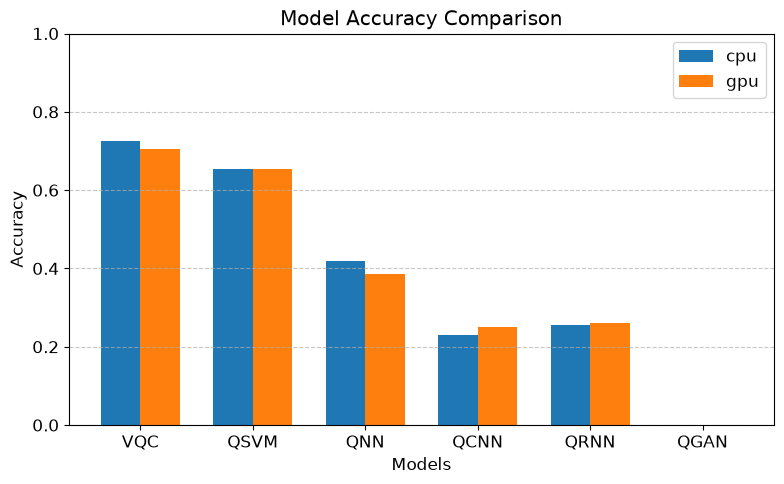

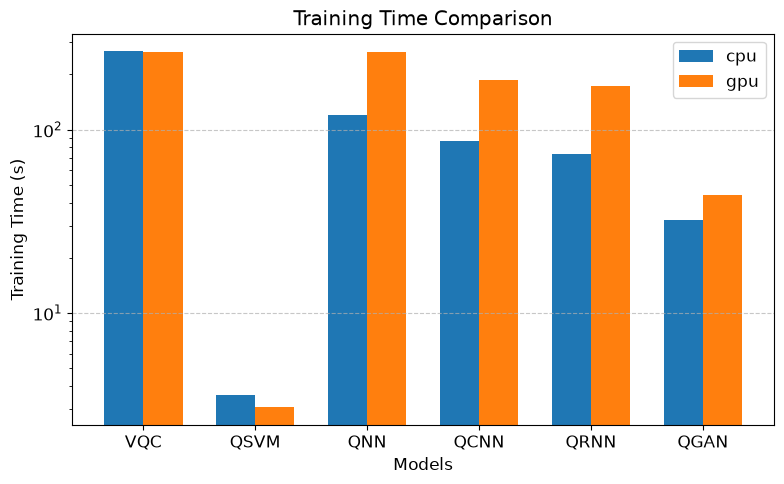


TABLE I: Performance Metrics for QML Models
Model CPU Accuracy GPU Accuracy IBM Quantum CPU Time (s) GPU Time (s)
  VQC          72%          70%         N/A        267.5        263.7
 QSVM          66%          66%         N/A          3.6          3.1
  QNN          42%          38%         N/A        119.9        266.4
 QCNN          23%          25%         N/A         86.6        186.9
 QRNN          26%          26%         N/A         74.0        172.6
 QGAN          N/A          N/A         N/A         32.3         44.2

--- LaTeX Code for your Paper ---
\begin{tabular}{|c|c|c|c|c|c|}
\toprule
Model & CPU Accuracy & GPU Accuracy & IBM Quantum & CPU Time (s) & GPU Time (s) \\
\midrule
VQC & 72% & 70% & N/A & 267.5 & 263.7 \\
QSVM & 66% & 66% & N/A & 3.6 & 3.1 \\
QNN & 42% & 38% & N/A & 119.9 & 266.4 \\
QCNN & 23% & 25% & N/A & 86.6 & 186.9 \\
QRNN & 26% & 26% & N/A & 74.0 & 172.6 \\
QGAN & N/A & N/A & N/A & 32.3 & 44.2 \\
\bottomrule
\end{tabular}



In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# 1. DATA EXTRACTION
# ==========================================
models = ['VQC', 'QSVM', 'QNN', 'QCNN', 'QRNN', 'QGAN']

# Helper to safely extract metrics, treating missing/None as 0 for plotting
def get_metric(backend, model, metric):
    try:
        val = all_results[backend][model].get(metric)
        return float(val) if val is not None else 0.0
    except KeyError:
        return 0.0

cpu_acc = [get_metric('cpu', m, 'accuracy') for m in models]
gpu_acc = [get_metric('gpu', m, 'accuracy') for m in models]

cpu_time = [get_metric('cpu', m, 'train_time') for m in models]
gpu_time = [get_metric('gpu', m, 'train_time') for m in models]

x = np.arange(len(models))  # the label locations
width = 0.35  # the width of the bars

# Configure Matplotlib for publication quality
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# ==========================================
# 2. PLOT: ACCURACY COMPARISON
# ==========================================
fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, cpu_acc, width, label='cpu', color='#1f77b4')
rects2 = ax.bar(x + width/2, gpu_acc, width, label='gpu', color='#ff7f0e')

ax.set_ylabel('Accuracy')
ax.set_xlabel('Models')
ax.set_title('Model Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)
ax.set_ylim([0, 1.0]) # Accuracy is usually 0 to 1

fig.tight_layout()
plt.savefig('model_accuracy_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 3. PLOT: TRAINING TIME COMPARISON (LOG SCALE)
# ==========================================
fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, cpu_time, width, label='cpu', color='#1f77b4')
rects2 = ax.bar(x + width/2, gpu_time, width, label='gpu', color='#ff7f0e')

ax.set_ylabel('Training Time (s)')
ax.set_xlabel('Models')
ax.set_title('Training Time Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Apply Logarithmic Scale (crucial for time comparisons in QML)
ax.set_yscale('log')

fig.tight_layout()
plt.savefig('training_time_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 4. GENERATE PUBLICATION TABLE (LaTeX & Text)
# ==========================================
print("\n" + "="*60)
print("TABLE I: Performance Metrics for QML Models")
print("="*60)

table_data = []
for m in models:
    # Format accuracy as percentages, handle N/A for models like QGAN
    c_acc = all_results.get('cpu', {}).get(m, {}).get('accuracy')
    g_acc = all_results.get('gpu', {}).get(m, {}).get('accuracy')
    ibm_acc = all_results.get('ibm_quantum_platform', {}).get(m, {}).get('accuracy')
    
    c_time = all_results.get('cpu', {}).get(m, {}).get('train_time')
    g_time = all_results.get('gpu', {}).get(m, {}).get('train_time')

    table_data.append({
        'Model': m,
        'CPU Accuracy': f"{c_acc*100:.0f}%" if c_acc is not None else "N/A",
        'GPU Accuracy': f"{g_acc*100:.0f}%" if g_acc is not None else "N/A",
        'IBM Quantum': f"{ibm_acc*100:.0f}%" if ibm_acc is not None else "N/A",
        'CPU Time (s)': f"{c_time:.1f}" if c_time is not None else "N/A",
        'GPU Time (s)': f"{g_time:.1f}" if g_time is not None else "N/A"
    })

df_paper = pd.DataFrame(table_data)

# Print a nice text version for the notebook
print(df_paper.to_string(index=False))

# Print the exact LaTeX code for your paper
print("\n--- LaTeX Code for your Paper ---")
print(df_paper.to_latex(index=False, column_format='|c|c|c|c|c|c|', escape=False))

In [22]:
# Display detailed summary table
print("\n" + "="*80)
print("DETAILED SUMMARY OF RESULTS")
print("="*80)

# Create summary DataFrame
import pandas as pd

summary_data = []
for backend, results in all_results.items():
    if 'error' in results:
        continue

    for model, metrics in results.items():
        if isinstance(metrics, dict):
            row = {
                'Backend': backend,
                'Model': model,
                'Accuracy': f"{metrics.get('accuracy', 'N/A'):.3f}" if isinstance(metrics.get('accuracy'), (int, float)) else 'N/A',
                'Training Time (s)': f"{metrics.get('train_time', 'N/A'):.2f}" if isinstance(metrics.get('train_time'), (int, float)) else 'N/A',
                'Iterations': metrics.get('iterations', 'N/A'),
                'Final Loss': f"{metrics.get('final_loss', 'N/A'):.4f}" if isinstance(metrics.get('final_loss'), (int, float)) else 'N/A'
            }
            summary_data.append(row)

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

# Performance comparison
print("\n" + "="*80)
print("PERFORMANCE COMPARISON")
print("="*80)

# Calculate speedups
if 'cpu' in all_results and 'gpu' in all_results:
    print("\nGPU Speedup vs CPU:")
    for model in ['VQC', 'QSVM', 'QNN', 'QCNN', 'QRNN']:
        if (model in all_results['cpu'] and model in all_results['gpu'] and
            'train_time' in all_results['cpu'][model] and
            'train_time' in all_results['gpu'][model]):
            cpu_time = all_results['cpu'][model]['train_time']
            gpu_time = all_results['gpu'][model]['train_time']
            speedup = cpu_time / gpu_time
            print(f"  {model}: {speedup:.2f}x faster")



DETAILED SUMMARY OF RESULTS
Backend Model Accuracy Training Time (s) Iterations Final Loss
    cpu   VQC    0.725            267.49        400        N/A
    cpu  QSVM    0.655              3.56        N/A        N/A
    cpu   QNN    0.420            119.86         10        N/A
    cpu  QCNN    0.230             86.58          5        N/A
    cpu  QRNN    0.255             74.00          5        N/A
    cpu  QGAN      N/A             32.29        N/A     0.9788
    gpu   VQC    0.705            263.69        400        N/A
    gpu  QSVM    0.655              3.06        N/A        N/A
    gpu   QNN    0.385            266.43         10        N/A
    gpu  QCNN    0.250            186.85          5        N/A
    gpu  QRNN    0.260            172.62          5        N/A
    gpu  QGAN      N/A             44.23        N/A     1.7247

PERFORMANCE COMPARISON

GPU Speedup vs CPU:
  VQC: 1.01x faster
  QSVM: 1.16x faster
  QNN: 0.45x faster
  QCNN: 0.46x faster
  QRNN: 0.43x faster
